In [1]:
# First let's import the relevant packages
import numpy as np
from scipy.special import spherical_jn, spherical_yn , hankel1,lpmv,jn
import matplotlib.pyplot as plt
import scipy.special as sc
import math
from matplotlib.colors import LogNorm

**Bellow we have the general Electrid Field that will be used**


# Mie Coefficients

In [2]:
def MieCoefCond2(x, n):
    """
    Compute the Mie scattering coefficients for a perfectly conducting sphere.

    This function calculates the Mie coefficients (a_n and b_n) for 
    a perfectly electrically conducting (PEC) material using spherical 
    Bessel functions of the first kind and spherical Hankel functions 
    of the first kind.

    Args:
        x (float or array-like): Size parameter (k * r), where k is the 
            wavenumber of the incident wave and r is the sphere radius. 
            Can be a scalar or a NumPy array.
        n (int): Order of the Mie coefficient to compute (n ≥ 1).

    Returns:
        tuple of complex:
            - a (complex): Mie coefficient a_n.
            - b (complex): Mie coefficient b_n.

    Notes:
        - Assumes the sphere is a perfect electric conductor (PEC).
        - Uses spherical Bessel functions (`spherical_jn`) and spherical 
          Hankel functions (`hankel1`).
        - The expressions follow standard Mie theory formulations for 
          conductive spheres.
    """
    # calculate the functions used in the calculations
    jn = spherical_jn(n, x)
    jn1 = spherical_jn(n+1,x)
    jn_1 = spherical_jn(n-1,x)
    
    hankeln = np.sqrt(np.pi/(2*x))*hankel1(n+1/2,x)
    hankeln1 = np.sqrt(np.pi/(2*x))*hankel1(n+1+1/2,x)
    hankeln_1 = np.sqrt(np.pi/(2*x))*hankel1(n-1+1/2,x)
    
    a = -(jn + x *1/2* (  x* (jn_1-jn1) + jn ))/(hankeln + x  *1/2* ( x*(hankeln_1-hankeln1) + hankeln))
    b = - jn/hankeln  
    
    return a, b

# Example usage
x = 1.0
n = 1
GTM = 2.0
GTE = 3.0


a, b = MieCoefCond2(x, n)
print("a:", a)
print("b:", b)

a: (-0.7080734182735715-0.45464871341284097j)
b: (-0.045351286587159194-0.2080734182735714j)


In python we do not have a package that calculate the spherical hankel functions of the first kind, so parting from the hankel function we can write them
\begin{equation}
    h_n^{(1)}(z) = \sqrt{ \frac{\pi}{2z}}H_{n+1/2}^{(1)}(z)
\end{equation}


In [3]:
def MieCoef(x, M, n):
    """
    Compute the general Mie scattering coefficients (a_n, b_n).

    This function calculates the Mie coefficients for a spherical 
    particle with relative refractive index M embedded in a medium. 
    The formulation is based on spherical Bessel functions of the 
    first kind and spherical Hankel functions of the first kind, 
    expressed in terms of Riccati–Bessel functions.

    Args:
        x (float): Size parameter of the sphere (x = k * r), where 
            k is the wavenumber in the surrounding medium and r is 
            the sphere radius.
        M (float or complex): Relative refractive index of the sphere 
            (n_particle / n_medium).
        n (int): Order of the coefficient to compute (n ≥ 1).

    Returns:
        tuple of complex:
            - a_n (complex): Electric-type Mie coefficient.
            - b_n (complex): Magnetic-type Mie coefficient.

    Notes:
        - a_n and b_n correspond to the scattering coefficients defined 
          in standard Mie theory.
        - This implementation uses Riccati–Bessel functions:
              ψ_n(z) = z * j_n(z)
              ζ_n(z) = z * h_n^(1)(z)
          and their derivatives with respect to z.
        - Coefficients c_n and d_n (related to internal fields) are 
          commented out but can be added if needed.
    """
    # Computing spherical Bessel functions for n and M*n
    j_n_x = spherical_jn(n, x)
    j_n_Mx = spherical_jn(n, M*x)

    # Computing Riccati-Bessel functions
    psi_n_x = x * j_n_x
    zeta_n_x = x * np.sqrt(np.pi/(2*x))*hankel1(n+1/2,x)

    psi_n_Mx = M * x * j_n_Mx
    zeta_n_Mx = M * x * np.sqrt(np.pi/(2*M*x))*hankel1(n+1/2,M*x)

    # Computing Riccati-Bessel function
    psi_n_x_prime = 1/2* (  x* (spherical_jn(n-1,x)-spherical_jn(n+1,x)) + spherical_jn(n,x) ) 
    
    zeta_n_x_prime = 1/2* np.sqrt(np.pi/(2*x))*(  x* (hankel1(n+1/2-1,x)-hankel1(n+1/2+1,x)) + hankel1(n+1/2,x) )

    psi_n_Mx_prime = 1/2* (  M*x* (spherical_jn(n-1,M*x)-spherical_jn(n+1,M*x)) + spherical_jn(n,M*x) ) 
    
    zeta_n_Mx_prime= 1/2* np.sqrt(np.pi/(2*M*x))*(  x* (hankel1(n+1/2-1,M*x)-hankel1(n+1/2+1,M*x)) + hankel1(n+1/2,M*x) )

    # Calculating coefficients a_n, b_n, c_n, d_n
    a_n = (M * psi_n_Mx * psi_n_x_prime - psi_n_Mx_prime * psi_n_x) / (psi_n_Mx_prime * zeta_n_x - M * psi_n_Mx * zeta_n_x_prime)
    b_n = (M * psi_n_Mx_prime * psi_n_x - psi_n_Mx * psi_n_x_prime) / (psi_n_Mx * zeta_n_x_prime - M * psi_n_Mx_prime * zeta_n_x)
    
    #c_n = (psi_n_x * zeta_n_x_prime - psi_n_x_prime * zeta_n_x) / (psi_n_Mx_prime * zeta_n_x - M * psi_n_Mx * zeta_n_x_prime)
    #d_n = (psi_n_x_prime * zeta_n_x - psi_n_x * zeta_n_x_prime) / (psi_n_Mx * zeta_n_x_prime - M * psi_n_Mx_prime * zeta_n_x)

    return a_n, b_n

# Test the function with scalar inputs
wavelength = 1
radius = 5
k = 2 * np.pi / wavelength
x_value = k * radius
print(MieCoef(x_value, 155/133, 30))


((-0.505726836616118-0.49996720226667923j), (-0.5041828204976252-0.49998250370656255j))


# Now the Field on Spherical Coordinates

In [4]:
def E_SCATnm(n, m, a_nm, b_nm, k, r, theta, phi):
    kr = k * r
    
    sph_hankel_n1 = np.sqrt(np.pi/(2*kr))*sc.hankel1(n+1 + 1/2,kr)
    sph_hankel_n = np.sqrt(np.pi/(2*kr))*sc.hankel1(n + 1/2,kr)
    sph_hankel_n_1 = np.sqrt(np.pi/(2*kr))*sc.hankel1(n-1 + 1/2,kr)

    dhn = 1/2 * ( k * sph_hankel_n_1 -  1/(r) *(sph_hankel_n) - k*sph_hankel_n1 )

    fac = math.factorial(n-abs(m))/math.factorial(n+abs(m))
    pre = 1j / np.sqrt(n * (n + 1)) * np.sqrt( (2 * n + 1) / (4 * np.pi) * fac )*  np.exp(1j*m*phi)/(np.sin(theta))

    if m>=0:
        P_nm=lpmv(m,n,np.cos(theta))
        P_nm1=lpmv(m,n+1,np.cos(theta))
        P_nm2=lpmv(m,n+2,np.cos(theta))

    if m<0:        
        #m = abs(m)
        P_nm=lpmv(abs(m),n,np.cos(theta))*(-1)**(m) 
        P_nm1=lpmv(abs(m),n+1,np.cos(theta))*(-1)**(m) 
        P_nm2=lpmv(abs(m),n+2,np.cos(theta))*(-1)**(m)

        


    dPnm = ( (n+1)*np.cos(theta) * P_nm + (-1+abs(m)-n)*P_nm1  )

    term1 = 1/2*(2 - 2*m**2 + 3*n + n**2 + n*(n+1)* np.cos(2*theta) )*P_nm
    term2 = (abs(m)-n-1) * ( ( 3 +2*n) *np.cos(theta)*P_nm1 + (-2 + abs(m) -n) * P_nm2 )
    dPnm1 = ( term1 + term2 )

    # --------
    

    E_0 = [ 0 *np.ones(len(dPnm)),           
            -dPnm       ,
            1j*m*P_nm 
    ]
    E_r0 = E_0[0]
    E_theta0 = E_0[1] * dhn * pre
    E_phi0 = E_0[2] * dhn * pre
    E_0 = np.array([E_r0 , E_theta0,E_phi0])


    E_1 = [ -1/(np.sin(theta)) * dPnm1 ,
            -dPnm,
           1j*m*P_nm  
    ]
    E_r1 = E_1[0] * 1/(r) * sph_hankel_n * pre
    E_theta1 = E_1[1] * 1/(r) * sph_hankel_n * pre
    E_phi1 = E_1[2] * 1/(r) * sph_hankel_n * pre
    E_1 = np.array([E_r1,E_theta1,E_phi1])
    
    E1= 1j*a_nm/k * (E_0 + E_1)
       
    #==================
    # Now the term with bnm which only has the X_nm(theta,phi)


    X_nm = [ 0*np.ones(len(dPnm)) ,
        1j * m * P_nm,
        dPnm ]#dPn ]


    E_r = X_nm[0]

    E_theta = b_nm * sph_hankel_n*X_nm[1] * pre
    
    E_phi =  b_nm * sph_hankel_n*X_nm[2] * pre
    
    E2 =  np.array([E_r,E_theta, E_phi])
    
    return E1+E2


**Comparing our code result with the giving by $\textit{MiePy}$**

In [5]:
# Constants
N = 200
wavelength = 0.65
radius = 1
k = 2 * np.pi / wavelength
x_value = k * radius
M = 1.33/1
phi = 0
theta = np.linspace(-np.pi,np.pi,300)
r = 1e4

# The incided field
E0_inc = np.array([np.sin(theta)*np.cos(phi)*np.exp(1j*k*r*np.cos(theta)) ,
                  np.cos(theta)*np.cos(phi)*np.exp(1j*k*r*np.cos(theta))  ,
                  -np.sin(phi)*np.ones(len(theta))*np.exp(1j*k*r*np.cos(theta))  ])  # Initialize the electric field array

# Iniciate the Scattered field calculation
E0_sca = 0
for i in range(1,N):
    #Calculate constants
    a_n, b_n = MieCoef(x_value, M, i) 
    
    Gn = -1 * 1j**(i+1) * np.sqrt((2*i +1)*np.pi)
    GnmTE = 1j*Gn
    Gn_1TE = 1j*Gn
    Gn1TM =   Gn
    Gn_1TM = - Gn

    # Calculate the Field
    E0_sca += E_SCATnm(i,1, a_n*Gn1TM, b_n*GnmTE, k, r, theta, phi)
    E0_sca += E_SCATnm(i,-1, a_n*Gn_1TM, b_n*Gn_1TE, k, r, theta, phi) 


# Also make it in the case that we have phi = pi/2
phi = np.pi/2  
E01_sca = 0

for i in range(1,N):
    a_n, b_n = MieCoef(x_value, M, i) 
    
    Gn = -1 * 1j**(i+1) * np.sqrt((2*i +1)*np.pi)
    GnmTE = 1j*Gn
    Gn_1TE = 1j*Gn
    Gn1TM =  Gn
    Gn_1TM =  -Gn

    # Calculate the Field
    E01_sca += E_SCATnm(i,1, a_n*Gn1TM, b_n*GnmTE, k, r, theta, phi)
    E01_sca += E_SCATnm(i,-1, a_n*Gn_1TM, b_n*Gn_1TE, k, r, theta, phi) 

In [6]:
import miepython

mu = np.cos(theta)
M2= M

Ipar, Iper = miepython.ez_intensities(M, 2*radius, wavelength, mu)

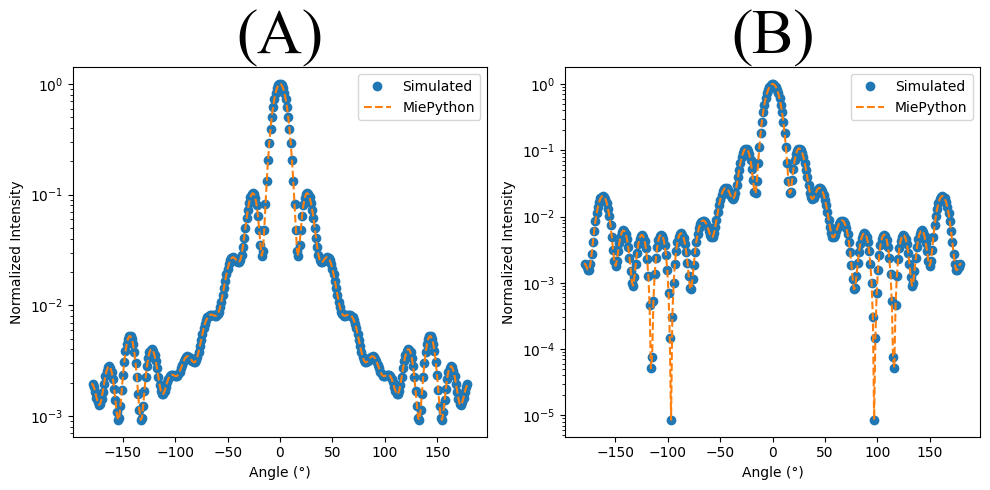

In [7]:
E = E0_sca
# Calculate the intensity seen as it is a function of the module squared of the field
U =  np.abs(E[0])**2 + np.abs(E[1])**2+np.abs(E[2])**2

fig,ax=plt.subplots(1,2,figsize=(10,5))
ax[0].plot(theta*180/np.pi, U/max(U),'o',label='Simulated')
ax[0].plot(theta*180/np.pi,Ipar/max(Ipar),'--',label='MiePython')
ax[0].legend()

ax[0].set_yscale('log')
ax[0].set_xlabel('Angle (°)')
ax[0].set_ylabel('Normalized Intensity')
ax[0].set_title('(A)', fontname='Times New Roman',fontsize=45)

E = E01_sca
U =  abs(E[0])**2 + abs(E[1])**2+abs(E[2])**2

ax[1].plot(theta*180/np.pi, U/max(U),'o',label='Simulated')
ax[1].plot(theta*180/np.pi,Iper/max(Iper),'--',label='MiePython')
ax[1].legend()

ax[1].set_yscale('log')
ax[1].set_xlabel('Angle (°)')
ax[1].set_ylabel('Normalized Intensity')
ax[1].set_title('(B)', fontname='Times New Roman',fontsize=45)

plt.tight_layout()
#plt.savefig('ComparaMiePython.png',dpi=300)

# Circle Image

To make an image such as the circle shown using Rayleigh-Sommerfeld formulation we should change the coordiantes to cartesian, it can be easily done by applying

\begin{align}
\hat{r} &= \cos\phi\sin\theta\hat{x}+\sin\phi\sin\theta\hat{y}+\cos\theta\hat{z} \\
\hat{\phi} &= -\sin\phi\hat{x} + \cos\phi\hat{y} \\
\hat{\theta} &= \cos\phi\cos\theta\hat{x} + \sin\phi\cos\theta\hat{y} -\sin\theta\hat{z}
\end{align}

First let's see for the incident field

In [95]:
def E1_Incnm(n,m, a_n, b_n, k, x, y, z):
    """
    Compute the scattered electric field vector in Cartesian coordinates 
    for a given multipole order n using Mie theory.

    Args:
        n (int): Multipole order of the expansion.
        a_n (complex): Mie coefficient 'a_n' associated with electric multipoles.
        b_n (complex): Mie coefficient 'b_n' associated with magnetic multipoles.
        k (float): Wavenumber of the incident light (2π/λ).
        x (float or np.ndarray): x-coordinate(s) where the field is evaluated.
        y (float or np.ndarray): y-coordinate(s) where the field is evaluated.
        z (float or np.ndarray): z-coordinate(s) where the field is evaluated.

    Returns:
        np.ndarray: A complex-valued array of shape (3, ...) containing the 
        scattered electric field components [E_x, E_y, E_z] in Cartesian coordinates.

    Notes:
        - Internally, the function converts (x, y, z) into spherical coordinates 
          (r, θ, φ) to evaluate the field, then transforms the result back to Cartesian form.
        - Associated Legendre polynomials and spherical Hankel functions are used 
          to compute the multipole contributions.
        - Special handling is applied for θ → 0 to avoid singularities, setting 
          limiting values for derivatives of Legendre polynomials.
        - The output is suitable for constructing field maps in real space.    
    """
    r = np.sqrt(x**2 + y**2 + z**2)
    phi = np.sign(y) * np.arccos(x/np.sqrt(x**2+y**2))
    theta = np.arccos(z / r)

    kr = k * r
    
    sph_hankel_n1 = spherical_jn(n+1 ,kr)
    sph_hankel_n = spherical_jn(n ,kr)
    sph_hankel_n_1 = spherical_jn(n-1,kr)

    dhn = 1/2 * ( k * sph_hankel_n_1 -  1/(r) *(sph_hankel_n) - k*sph_hankel_n1 )

    fac = math.factorial(n-abs(m))/math.factorial(n+abs(m))
    pre = 1j / np.sqrt(n * (n + 1)) * np.sqrt( (2 * n + 1) / (4 * np.pi) * fac )*  np.exp(1j*m*phi)/(np.sin(theta))

    if m>=0:
        P_nm=lpmv(m,n,np.cos(theta))
        P_nm1=lpmv(m,n+1,np.cos(theta))
        P_nm2=lpmv(m,n+2,np.cos(theta))

    if m<0:
        #m = abs(m)
        P_nm=lpmv(abs(m),n,np.cos(theta))*(-1)**(m) 
        P_nm1=lpmv(abs(m),n+1,np.cos(theta))*(-1)**(m) 
        P_nm2=lpmv(abs(m),n+2,np.cos(theta))*(-1)**(m) 

        


    dPnm = ( (n+1)*np.cos(theta) * P_nm + (-1+abs(m)-n)*P_nm1  )

    term1 = (2 - 2*m**2 + 3*n + n**2 + n*(n+1)* np.cos(2*theta) )*P_nm
    term2 = 2* (abs(m)-n-1) * ( ( 3 +2*n) *np.cos(theta)*P_nm1 + (-2 + abs(m) -n) * P_nm2 )
    dPnm1 = ( term1 + term2 )

    # --------
    

    E_0 = [ 0 *dPnm,           
            -dPnm       ,
            1j*m*P_nm 
    ]
    E_r0 = E_0[0]
    E_theta0 = E_0[1] * dhn * pre
    E_phi0 = E_0[2] * dhn * pre
    E_0 = np.array([E_r0 , E_theta0,E_phi0])


    E_1 = [ -1/(2*np.sin(theta)) * dPnm1 ,
            -dPnm,
           1j*m*P_nm  
    ]
    E_r1 = E_1[0] * 1/(r) * sph_hankel_n * pre
    E_theta1 = E_1[1] * 1/(r) * sph_hankel_n * pre
    E_phi1 = E_1[2] * 1/(r) * sph_hankel_n * pre
    E_1 = np.array([E_r1,E_theta1,E_phi1])
    
    E1= 1j*a_n/k * (E_0 + E_1)
       
    #==================
    # Now the term with bnm which only has the X_nm(theta,phi)


    X_nm = [ 0*dPnm ,
        1j * m * P_nm,
        dPnm ]#dPn ]


    E_r = X_nm[0]

    E_theta = b_n * sph_hankel_n*X_nm[1] * pre
    
    E_phi =  b_n * sph_hankel_n*X_nm[2] * pre
    
    E2 =  np.array([E_r,E_theta, E_phi])
    Et = E1+E2

    term_r = Et[0]
    term_the = Et[1]
    term_phi = Et[2]

    return (np.array([term_r * np.cos(phi) * np.sin(theta), term_r * np.sin(theta) * np.sin(phi), term_r * np.cos(theta)]) +
                     np.array([term_the * np.cos(phi) * np.cos(theta), term_the * np.cos(theta) * np.sin(phi), -term_the * np.sin(theta)]) +
                     np.array([-term_phi * np.sin(phi), term_phi * np.cos(phi), np.zeros_like(r)]))


In [96]:
# Constants
N = 2000
wavelength = 0.65
radius = 100
k = 2 * np.pi / wavelength
x_value = k * radius

n = 300
x = np.linspace(-1.2*radius,1.2*radius,n)
y = 0
z = 1000

# The incided field
EE_inc = np.array([np.ones(n)*np.exp(1j*k*z), 
                   0*np.ones(n),
                   0*np.ones(n)])

# Iniciate the Scattered field calculation
E01_sca = 0

for i in range(1,N):
    a_n, b_n = 1,1#MieCoefCond2(x_value, i) 
    
    Gn = -1 * 1j**(i+1) * np.sqrt((2*i +1)*np.pi)
    GnmTE = 1j*Gn
    Gn_1TE = 1j*Gn
    Gn1TM =  Gn
    Gn_1TM =  -Gn

    # Calculate the Field

    if np.isnan(np.abs(a_n)) or np.isnan(np.abs(b_n)) :
        print('Limit Achived')
        break

    # Calculate the Field
    E01_sca += E1_Incnm(i,1, a_n*Gn1TM, b_n*GnmTE, k, x, y, z)
    E01_sca += E1_Incnm(i,-1, a_n*Gn_1TM, b_n*Gn_1TE, k, x, y, z) 

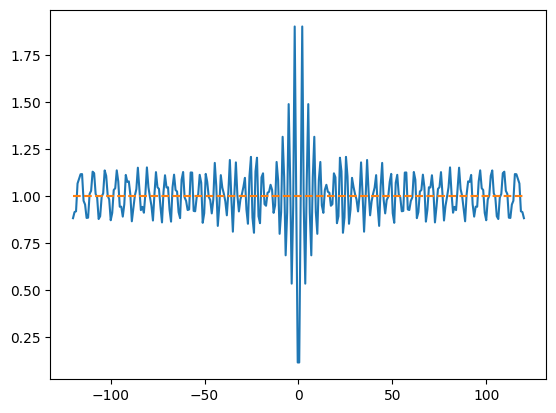

In [97]:
E = E01_sca #+ EE_inc
# Calculate the intensity seen as it is a function of the module squared of the field
U =  abs(E[0])**2 + abs(E[1])**2 + abs(E[2])**2
U2 =  abs(E01_sca[0])**2 + abs(E01_sca[1])**2 + abs(E01_sca[2])**2
U0 = abs(EE_inc[0])**2 + abs(EE_inc[1])**2+abs(EE_inc[2])**2

#plt.plot(x, U,'o',label='Simulated')
plt.plot(x, U2,'-',label='Simulated')
plt.plot(x, U0,'--',label='Simulated')

#plt.xlim(-10,10)

Now for the scattered

In [8]:
def E1_SCATnm(n,m, a_n, b_n, k, x, y, z):
    """
    Compute the scattered electric field vector in Cartesian coordinates 
    for a given multipole order n using Mie theory.

    Args:
        n (int): Multipole order of the expansion.
        a_n (complex): Mie coefficient 'a_n' associated with electric multipoles.
        b_n (complex): Mie coefficient 'b_n' associated with magnetic multipoles.
        k (float): Wavenumber of the incident light (2π/λ).
        x (float or np.ndarray): x-coordinate(s) where the field is evaluated.
        y (float or np.ndarray): y-coordinate(s) where the field is evaluated.
        z (float or np.ndarray): z-coordinate(s) where the field is evaluated.

    Returns:
        np.ndarray: A complex-valued array of shape (3, ...) containing the 
        scattered electric field components [E_x, E_y, E_z] in Cartesian coordinates.

    Notes:
        - Internally, the function converts (x, y, z) into spherical coordinates 
          (r, θ, φ) to evaluate the field, then transforms the result back to Cartesian form.
        - Associated Legendre polynomials and spherical Hankel functions are used 
          to compute the multipole contributions.
        - Special handling is applied for θ → 0 to avoid singularities, setting 
          limiting values for derivatives of Legendre polynomials.
        - The output is suitable for constructing field maps in real space.    
    """
    r = np.sqrt(x**2 + y**2 + z**2)
    phi = np.sign(y) * np.arccos(x/np.sqrt(x**2+y**2))
    theta = np.arccos(z / r)

    kr = k * r
    
    sph_hankel_n1 = np.sqrt(np.pi/(2*kr))*sc.hankel1(n+1 + 1/2,kr)
    sph_hankel_n = np.sqrt(np.pi/(2*kr))*sc.hankel1(n + 1/2,kr)
    sph_hankel_n_1 = np.sqrt(np.pi/(2*kr))*sc.hankel1(n-1 + 1/2,kr)

    dhn = 1/2 * ( k * sph_hankel_n_1 -  1/(r) *(sph_hankel_n) - k*sph_hankel_n1 )

    fac = math.factorial(n-abs(m))/math.factorial(n+abs(m))
    pre = 1j / np.sqrt(n * (n + 1)) * np.sqrt( (2 * n + 1) / (4 * np.pi) * fac )*  np.exp(1j*m*phi)/(np.sin(theta))

    if m>=0:
        P_nm=lpmv(m,n,np.cos(theta))
        P_nm1=lpmv(m,n+1,np.cos(theta))
        P_nm2=lpmv(m,n+2,np.cos(theta))

    if m<0:
        #m = abs(m)
        P_nm=lpmv(abs(m),n,np.cos(theta))*(-1)**(m) 
        P_nm1=lpmv(abs(m),n+1,np.cos(theta))*(-1)**(m) 
        P_nm2=lpmv(abs(m),n+2,np.cos(theta))*(-1)**(m) 

        


    dPnm = ( (n+1)*np.cos(theta) * P_nm + (-1+abs(m)-n)*P_nm1  )

    term1 = (2 - 2*m**2 + 3*n + n**2 + n*(n+1)* np.cos(2*theta) )*P_nm
    term2 = 2* (abs(m)-n-1) * ( ( 3 +2*n) *np.cos(theta)*P_nm1 + (-2 + abs(m) -n) * P_nm2 )
    dPnm1 = ( term1 + term2 )

    # --------
    

    E_0 = [ 0 *dPnm,           
            -dPnm       ,
            1j*m*P_nm 
    ]
    E_r0 = E_0[0]
    E_theta0 = E_0[1] * dhn * pre
    E_phi0 = E_0[2] * dhn * pre
    E_0 = np.array([E_r0 , E_theta0,E_phi0])


    E_1 = [ -1/(2*np.sin(theta)) * dPnm1 ,
            -dPnm,
           1j*m*P_nm  
    ]
    E_r1 = E_1[0] * 1/(r) * sph_hankel_n * pre
    E_theta1 = E_1[1] * 1/(r) * sph_hankel_n * pre
    E_phi1 = E_1[2] * 1/(r) * sph_hankel_n * pre
    E_1 = np.array([E_r1,E_theta1,E_phi1])
    
    E1= 1j*a_n/k * (E_0 + E_1)
       
    #==================
    # Now the term with bnm which only has the X_nm(theta,phi)


    X_nm = [ 0*dPnm ,
        1j * m * P_nm,
        dPnm ]#dPn ]


    E_r = X_nm[0]

    E_theta = b_n * sph_hankel_n*X_nm[1] * pre
    
    E_phi =  b_n * sph_hankel_n*X_nm[2] * pre
    
    E2 =  np.array([E_r,E_theta, E_phi])
    Et = E1+E2

    term_r = Et[0]
    term_the = Et[1]
    term_phi = Et[2]

    return (np.array([term_r * np.cos(phi) * np.sin(theta), term_r * np.sin(theta) * np.sin(phi), term_r * np.cos(theta)]) +
                     np.array([term_the * np.cos(phi) * np.cos(theta), term_the * np.cos(theta) * np.sin(phi), -term_the * np.sin(theta)]) +
                     np.array([-term_phi * np.sin(phi), term_phi * np.cos(phi), np.zeros_like(r)]))


In [37]:
# Constants
N = 2000
wavelength = 0.65
radius = 100
k = 2 * np.pi / wavelength
x_value = k * radius

n = 450
x = 0#np.linspace(-1.2*radius,1.2*radius,n)
y = np.linspace(-1.2*radius,1.2*radius,n)
z = 1000

# The incided field
EE_inc = np.array([0*np.ones(n)*np.exp(1j*k*z), 
                   np.ones(n)*np.exp(1j*k*z),
                   0*np.ones(n)])

# Iniciate the Scattered field calculation
E01_sca = 0

for i in range(1,N):
    a_n, b_n = MieCoefCond2(x_value, i) 
    
    Gn = -1 * 1j**(i+1) * np.sqrt((2*i +1)*np.pi)
    #GnmTE = 1j*Gn
    #Gn_1TE = 1j*Gn
    #Gn1TM =  Gn
    #Gn_1TM =  -Gn
    GnmTE = Gn
    Gn_1TE = -Gn
    Gn1TM =  -1j*Gn
    Gn_1TM =  -1j*Gn
    # Calculate the Field

    if np.isnan(np.abs(a_n)) or np.isnan(np.abs(b_n)) :
        print('Limit Achived')
        break

    # Calculate the Field
    E01_sca += E1_SCATnm(i,1, a_n*Gn1TM, b_n*GnmTE, k, x, y, z)
    E01_sca += E1_SCATnm(i,-1, a_n*Gn_1TM, b_n*Gn_1TE, k, x, y, z) 

Limit Achived


C:\Users\user\AppData\Local\Temp\ipykernel_9628\517534407.py:37: RuntimeWarning: invalid value encountered in scalar divide
  a = -(jn + x *1/2* (  x* (jn_1-jn1) + jn ))/(hankeln + x  *1/2* ( x*(hankeln_1-hankeln1) + hankeln))


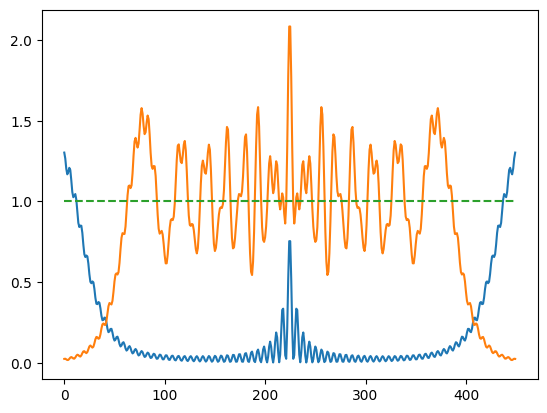

In [38]:
E = E01_sca + EE_inc
# Calculate the intensity seen as it is a function of the module squared of the field
U =  abs(E[0])**2 + abs(E[1])**2 + abs(E[2])**2
U2 =  abs(E01_sca[0])**2 + abs(E01_sca[1])**2+abs(E01_sca[2])**2
U0 = abs(EE_inc[0])**2 + abs(EE_inc[1])**2+abs(EE_inc[2])**2

plt.plot(U,'-',label='Simulated')
plt.plot(U2,'-',label='Simulated')
plt.plot(U0,'--',label='Simulated')

#plt.xlim(-10,10)

# Now some examples

---
For a y polarized field
\begin{equation}
    \vec{E}_{inc} = \hat{y}\exp{\left(\mathrm{i}kz\right)}
\end{equation}

we have a small difference where

\begin{equation}
    G_{n,\pm 1}^{TE} = \pm G_n 
\end{equation}

\begin{equation}
    G_{n,\pm 1}^{TM} = -i ~ G_n 
\end{equation}

with $G_n = -i^{n+1}\sqrt{(2n+)\pi}$

In [47]:
# Constants
N = 2000
wavelength = 0.632
radius = 100
k = 2 * np.pi / wavelength
x_value = k * radius

x= np.linspace(0.0001,1.2*radius,450)
x,y = np.meshgrid(x,x)

z = 1000

EE_sca = 0  # Initialize the electric field array
#E_inc = np.array([np.ones(len(x))*0,np.ones(len(x))*0,0*np.ones(len(x)) ])

for i in range(1,N):
    a_nm, b_nm = MieCoefCond2(x_value, i)
    if np.isnan(np.abs(a_nm)) or np.isnan(np.abs(b_nm)) :
        print('Limit Achived')
        break
    Gn = -1 * 1j**(i+1) * np.sqrt((2*i +1)*np.pi)
    GnmTE = Gn
    Gn_1TE = -Gn
    Gn1TM =  -1j*Gn
    Gn_1TM =  -1j*Gn
    # Calculate the scattered electric field for both m=1 
    EE_sca += E1_SCATnm(i,1, a_nm*Gn1TM, b_nm*GnmTE, k, x, y, z)
    EE_sca += E1_SCATnm(i,-1, a_nm*Gn_1TM, b_nm*Gn_1TE, k, x, y, z)


Limit Achived


C:\Users\user\AppData\Local\Temp\ipykernel_9628\517534407.py:37: RuntimeWarning: invalid value encountered in scalar divide
  a = -(jn + x *1/2* (  x* (jn_1-jn1) + jn ))/(hankeln + x  *1/2* ( x*(hankeln_1-hankeln1) + hankeln))


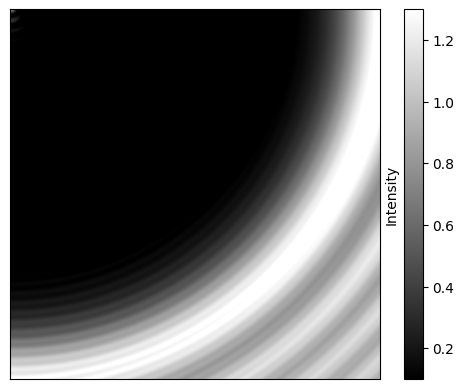

In [48]:
n=450
EE_inc = np.array([0*np.ones(n*n).reshape(n,n), 
                   1*np.ones(n*n).reshape(n,n)*np.exp(1j*k*z),
                   0*np.ones(n*n).reshape(n,n)])
EE = EE_inc+EE_sca
UU = np.abs(EE[0])**2 + np.abs(EE[1])**2 + np.abs(EE[2])**2

img = plt.imshow(UU,cmap='gray',vmin=0.1,vmax=1.3)
plt.yticks([])
plt.xticks([])
cbar = plt.colorbar(img)
cbar.set_label("Intensity")  # Adjust the distance and position
cbar.ax.yaxis.set_label_position("left")  # Ensure the label is on the right side


#plt.savefig('Mie.svg',dpi=300)

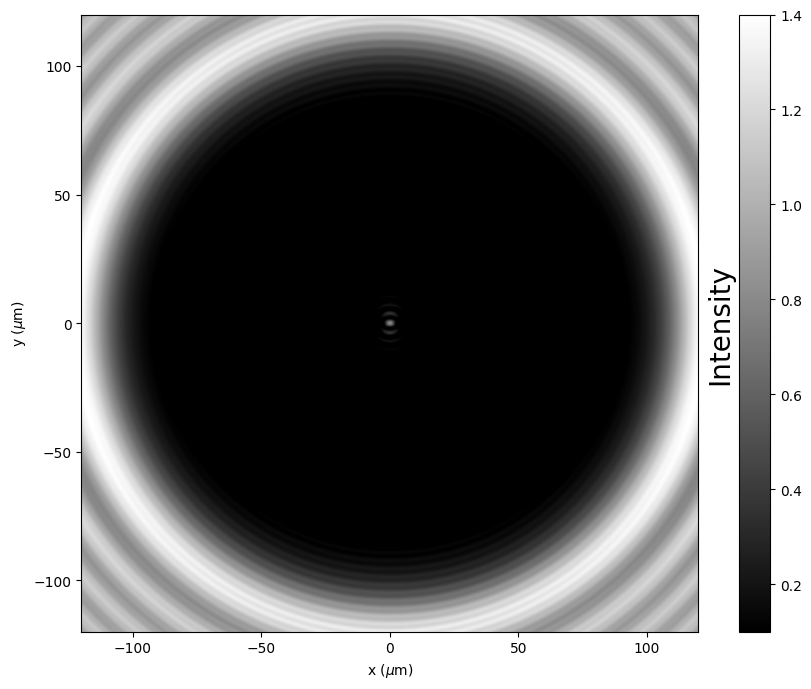

In [49]:
# Mirror the data along both axes
UU_full = np.block([
    [np.flip(np.flip(UU, axis=0), axis=1), np.flip(UU, axis=0)],
    [np.flip(UU, axis=1), UU]
])

fig = plt.subplots(figsize=(9,7))
# Plot the full figure
img = plt.imshow(UU_full, cmap='gray',aspect='equal', vmin=0.1, vmax=1.4,
                 extent=[-1.2 * radius, 1.2 * radius, -1.2 * radius, 1.2 * radius])
#plt.yticks([])
#plt.xticks([])
plt.xlabel(r'x ($\mu$m)')
plt.ylabel(r'y ($\mu$m)')

cbar = plt.colorbar(img)
cbar.set_label("Intensity",fontsize=20)  # Adjust the distance and position
cbar.ax.yaxis.set_label_position("left")  # Ensure the label is on the right side
# Save the figure
plt.tight_layout()
plt.savefig('MieEy.svg', dpi=300)
plt.show()

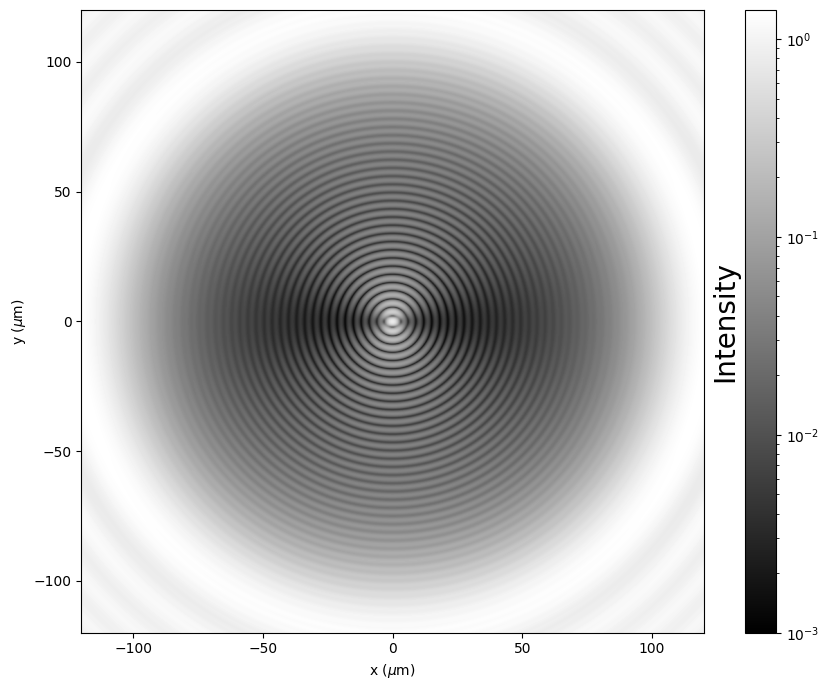

In [50]:
# Mirror the data along both axes
UU_full = np.block([
    [np.flip(np.flip(UU, axis=0), axis=1), np.flip(UU, axis=0)],
    [np.flip(UU, axis=1), UU]
])

fig = plt.subplots(figsize=(9,7))
# Plot the full figure
img = plt.imshow(UU_full, cmap='gray',aspect='equal', norm=LogNorm(vmin=1e-3, vmax=1.4),
                 extent=[-1.2 * radius, 1.2 * radius, -1.2 * radius, 1.2 * radius])
#plt.yticks([])
#plt.xticks([])
plt.xlabel(r'x ($\mu$m)')
plt.ylabel(r'y ($\mu$m)')

cbar = plt.colorbar(img)
cbar.set_label("Intensity",fontsize=20)  # Adjust the distance and position
cbar.ax.yaxis.set_label_position("left")  # Ensure the label is on the right side
# Save the figure
plt.tight_layout()
plt.savefig('MieEyLOG.svg', dpi=300)
plt.show()

---
If the field was circularly polarized

\begin{equation}
    \vec{E}_{inc} = (\hat{x}+\mathrm{i}\hat{y})\exp{\left(\mathrm{i}kz\right)}
\end{equation}


we have a small difference where

\begin{equation}
    G_{n,\pm 1}^{TE} = (i \pm i) G_n 
\end{equation}

\begin{equation}
    G_{n,\pm 1}^{TM} = (1 \pm 1) G_n 
\end{equation}

with $G_n = -i^{n+1}\sqrt{(2n+)\pi}$

In [61]:
# Constants
N = 2000
wavelength = 0.632
radius = 100
k = 2 * np.pi / wavelength
x_value = k * radius
#y=0
x= np.linspace(0.0001,1.2*radius,450)
x,y = np.meshgrid(x,x)

z = 1000

EE2_sca = 0  # Initialize the electric field array
#E_inc = np.array([np.ones(len(x))*0,np.ones(len(x))*0,0*np.ones(len(x)) ])

for i in range(1,N):
    a_nm, b_nm = MieCoefCond2(x_value, i)
    if np.isnan(np.abs(a_nm)) or np.isnan(np.abs(b_nm)) :
        print('Limit Achived')
        break

    Gn = -1 * 1j**(i+1) * np.sqrt((2*i +1)*np.pi)
    GnmTE = (1j + 1j)*Gn
    Gn_1TE = (-1j + 1j)*Gn
    Gn1TM =  (1+1)*Gn
    Gn_1TM =  (1-1)*Gn
    # Calculate the scattered electric field for both m=1 
    EE2_sca += E1_SCATnm(i,1, a_nm*Gn1TM, b_nm*GnmTE, k, x, y, z)
    EE2_sca += E1_SCATnm(i,-1, a_nm*Gn_1TM, b_nm*Gn_1TE, k, x, y, z)


Limit Achived


C:\Users\user\AppData\Local\Temp\ipykernel_9628\517534407.py:37: RuntimeWarning: invalid value encountered in scalar divide
  a = -(jn + x *1/2* (  x* (jn_1-jn1) + jn ))/(hankeln + x  *1/2* ( x*(hankeln_1-hankeln1) + hankeln))


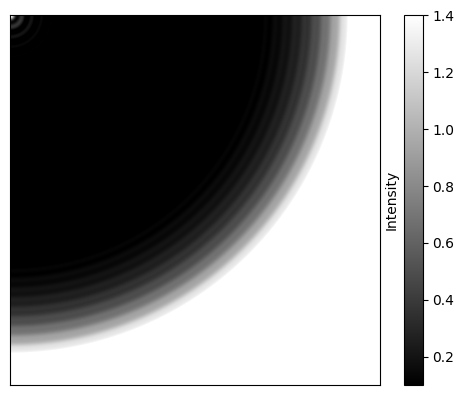

In [62]:
n=450
EE2_inc = np.array([np.ones(n*n).reshape(n,n)*np.exp(1j*k*z), 
                   1j*np.ones(n*n).reshape(n,n)*np.exp(1j*k*z),
                   0*np.ones(n*n).reshape(n,n)])

EE2 = EE2_inc+EE2_sca
UU2 = np.abs(EE2[0])**2 + np.abs(EE2[1])**2 + np.abs(EE2[2])**2

img = plt.imshow(UU2,cmap='gray',vmin=0.1,vmax=1.4)
plt.yticks([])
plt.xticks([])
cbar = plt.colorbar(img)
cbar.set_label("Intensity")  # Adjust the distance and position
cbar.ax.yaxis.set_label_position("left")  # Ensure the label is on the right side


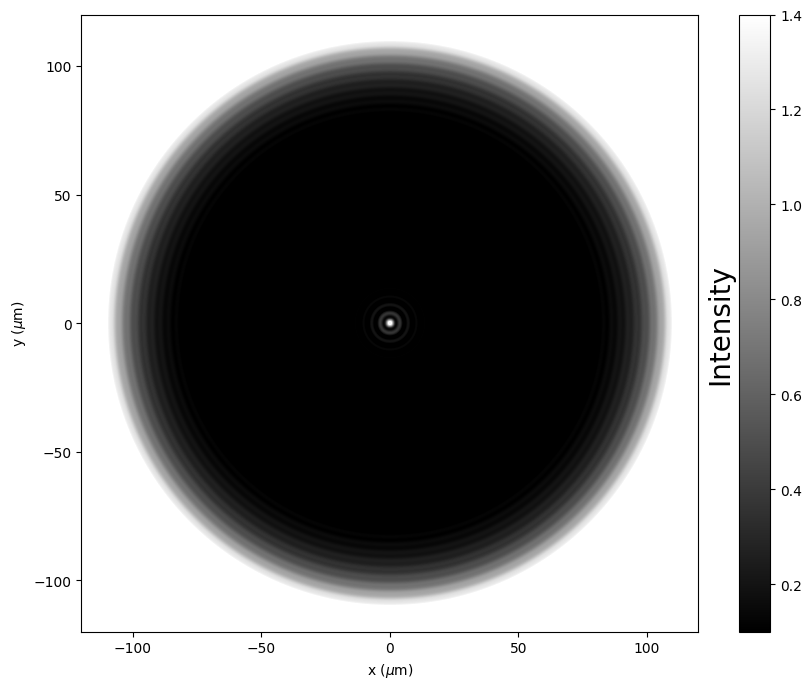

In [63]:
# Mirror the data along both axes
UU2_full = np.block([
    [np.flip(np.flip(UU2, axis=0), axis=1), np.flip(UU2, axis=0)],
    [np.flip(UU2, axis=1), UU2]
])

fig = plt.subplots(figsize=(9,7))
# Plot the full figure
img = plt.imshow(UU2_full, cmap='gray',aspect='equal', vmin=0.1, vmax=1.4,
                 extent=[-1.2 * radius, 1.2 * radius, -1.2 * radius, 1.2 * radius])
#plt.yticks([])
#plt.xticks([])
plt.xlabel(r'x ($\mu$m)')
plt.ylabel(r'y ($\mu$m)')

cbar = plt.colorbar(img)
cbar.set_label("Intensity",fontsize=20)  # Adjust the distance and position
cbar.ax.yaxis.set_label_position("left")  # Ensure the label is on the right side
# Save the figure
plt.tight_layout()
plt.savefig('MieEcirc.svg', dpi=300)
plt.show()

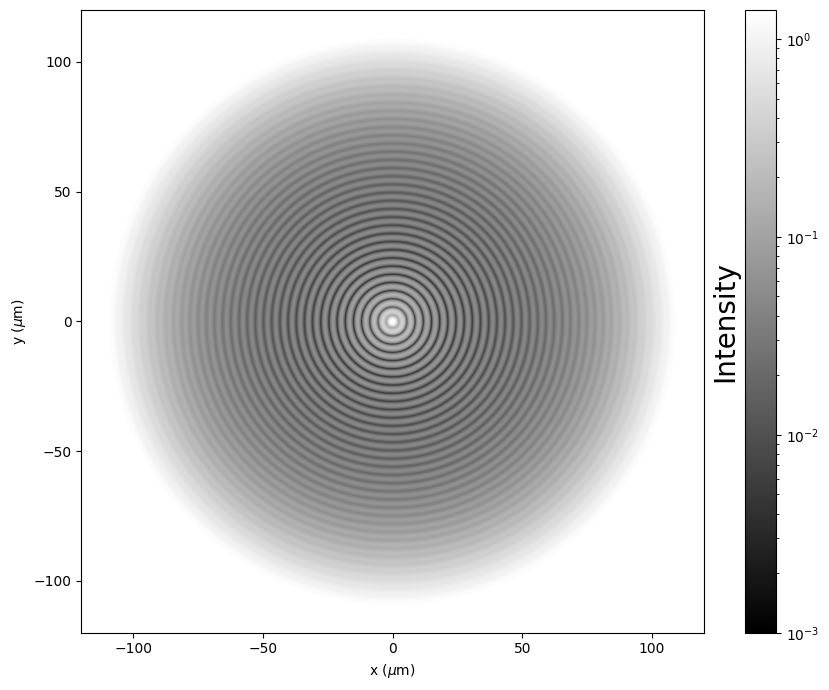

In [64]:
fig = plt.subplots(figsize=(9,7))
# Plot the full figure
img = plt.imshow(UU2_full, cmap='gray',aspect='equal', norm=LogNorm(vmin=1e-3, vmax=1.4),
                 extent=[-1.2 * radius, 1.2 * radius, -1.2 * radius, 1.2 * radius])
#plt.yticks([])
#plt.xticks([])
plt.xlabel(r'x ($\mu$m)')
plt.ylabel(r'y ($\mu$m)')

cbar = plt.colorbar(img)
cbar.set_label("Intensity",fontsize=20)  # Adjust the distance and position
cbar.ax.yaxis.set_label_position("left")  # Ensure the label is on the right side
# Save the figure
plt.tight_layout()
plt.savefig('MieEcircLOG.svg', dpi=300)
plt.show()

# Now looking at the spherical Hankel

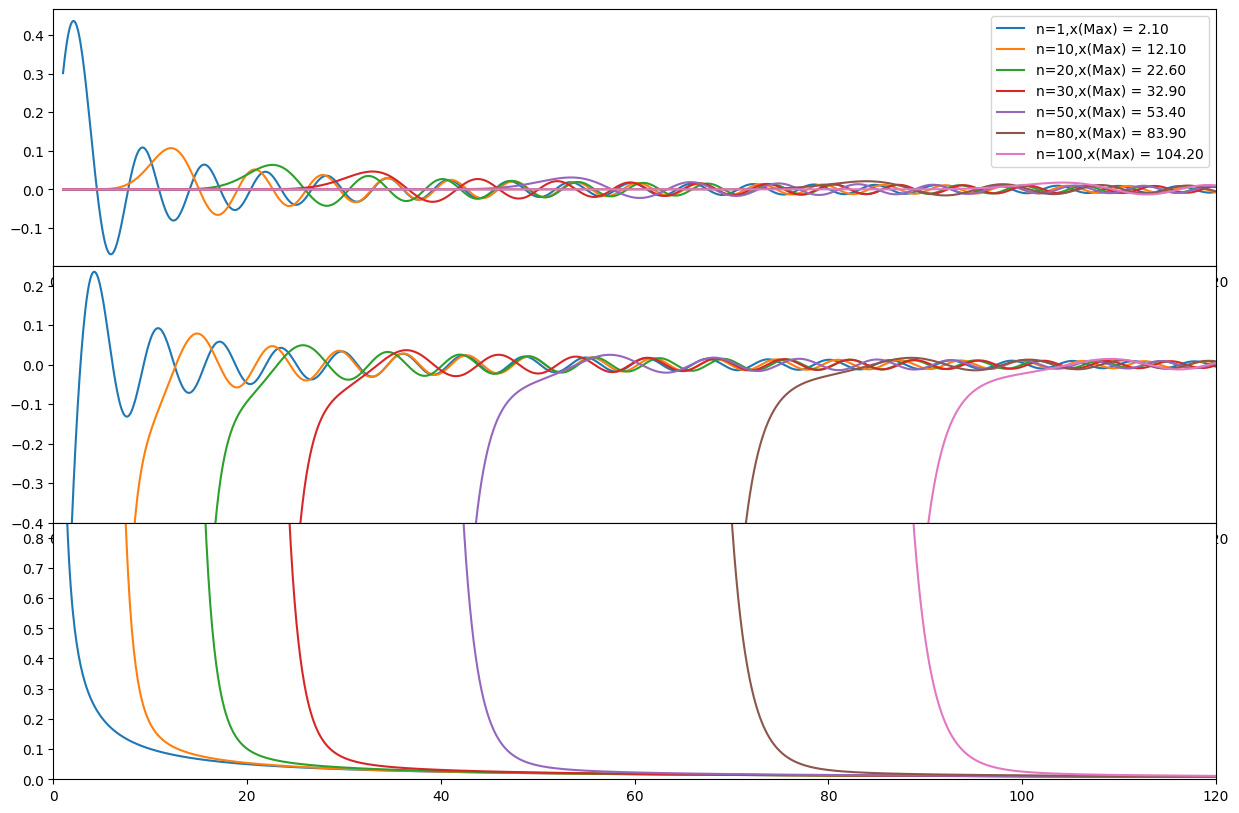

In [106]:
II = []
II2 = []
x = np.arange(1,130,0.1)
ns = [1,10,20,30,50,80,100]

fig = plt.figure(figsize=(15,10))
gs = plt.GridSpec(3,1,hspace=0)
ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1], sharex=ax0)
ax2 = fig.add_subplot(gs[2], sharex=ax0)

jns = 0
yns = 0
for i in ns:
    jns+=spherical_jn(i,x)
    ax0.plot(x,spherical_jn(i,x),label=f'n={i},x(Max) = {x[np.argmax(spherical_jn(i,x))]:.2f}')
    ax1.plot(x,spherical_yn(i,x),label=f'n={i}')
    ax2.plot(x, abs(spherical_jn(i,x) + 1j*spherical_yn(i,x)))
    yns+=spherical_yn(i,x)

#ax0.plot(x,jns,'--',lw=3)
#ax1.plot(x,yns,'--',lw=3)
#ax2.plot(x,np.array())
ax1.set_ylim(-0.4,0.25)
ax2.set_ylim(0,0.85)
ax0.set_xlim(0,120)

ax0.legend()